In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Load CSV
url = "https://raw.githubusercontent.com/PeiyaoPearl/CASA0006-Data-Science-for-Spatial-Systems-/refs/heads/main/Assessments/data/Ltds_clean.csv"
df = pd.read_csv(url)

current_rows = len(df)
print(f"Current number of records loaded: {current_rows}, containing {len(df.columns)} variables.")

# Count the number of records each year
year_counts = df['year'].value_counts().sort_index()

print("Total trip records per year:")
print(year_counts)

# Calculate percentage
year_percentage = df['year'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage per year (%):")
print(year_percentage.round(2))

Current number of records loaded: 220183, containing 18 variables.
Total trip records per year:
year
2014    36327
2015    39066
2016    36663
2017    35375
2018    35626
2019    37126
Name: count, dtype: int64

Percentage per year (%):
year
2014   16.50
2015   17.74
2016   16.65
2017   16.07
2018   16.18
2019   16.86
Name: proportion, dtype: float64


In [35]:
df.head()

,unique_trip_id,year,mode,distance_(km),journey_purpose,trip_start_time_period,origin_borough,gender,age,car_access,working_status,household_income,disability,ethnicity,household_structure,borough_mean_ptal,borough_pop_density,road_density
0,190010210101,2019,walk,1.07,shopping and personal business,am peak (0700-0959),barking & dagenham,female,32,no car,not working,10000 - 14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
1,190010210102,2019,walk,1.07,shopping and personal business,interpeak (1000-1559),barking & dagenham,female,32,no car,not working,10000 - 14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
2,190010510301,2019,pt,15.19,usual workplace,am peak (0700-0959),barking & dagenham,male,35,two or more car,full-time worker,75000 - 99999,not disabled,asian,couple without children,8.42,6530.50,9.59
3,190010510302,2019,pt,15.19,usual workplace,evening (1900-2159),islington,male,35,two or more car,full-time worker,75000 - 99999,not disabled,asian,couple without children,25.40,15129.70,15.94
4,190010710101,2019,pt,15.91,education,am peak (0700-0959),barking & dagenham,male,55,one car,part-time worker,5000 - 9999,not disabled,asian,lone parent,8.42,6530.50,9.59


In [36]:
# Drop the specified columns including year
columns_to_drop = ['unique_trip_id', 'origin_borough', 'year']
df = df.drop(columns=columns_to_drop)

# Verify the changes
print(f"Columns removed: {columns_to_drop}")
print(f"Current number of variables: {len(df.columns)}")

# Check the number of NaN values for each column in the entire table
nan_counts = df.isnull().sum()

# Check the percentage of missing values for the entire table (%)
nan_percentage = (df.isnull().sum() / len(df)) * 100

# Specifically check the household_income column
income_nan = df['household_income'].isnull().sum()

print("--- Missing Value Statistics (Total NaN Counts) ---")
print(nan_counts)
print("\n--- Missing Value Percentage (%) ---")
print(nan_percentage)
print(f"\nThe household_income column has {income_nan} NaN values.")

Columns removed: ['unique_trip_id', 'origin_borough', 'year']
Current number of variables: 15
--- Missing Value Statistics (Total NaN Counts) ---
mode                      0
distance_(km)             0
journey_purpose           0
trip_start_time_period    0
gender                    0
age                       0
car_access                0
working_status            0
household_income          0
disability                0
ethnicity                 0
household_structure       0
borough_mean_ptal         0
borough_pop_density       0
road_density              0
dtype: int64

--- Missing Value Percentage (%) ---
mode                     0.00
distance_(km)            0.00
journey_purpose          0.00
trip_start_time_period   0.00
gender                   0.00
age                      0.00
car_access               0.00
working_status           0.00
household_income         0.00
disability               0.00
ethnicity                0.00
household_structure      0.00
borough_mean_ptal      

EDA

In [37]:
# Set display resolution
pd.set_option('display.float_format', lambda x: '%.2f' % x)

def generate_academic_table(df):
    results = []

    # --- A. Dependent Variable (mode) ---
    results.append({'Variable': 'Dependent variable', 'Proportion/Mean': '', 'SD': ''})
    counts = df['mode'].value_counts(normalize=True) * 100
    for category, prop in counts.items():
        results.append({'Variable': f'  {category} (%)', 'Proportion/Mean': prop, 'SD': '-'})

    # --- B. Independent Variables (Numerical) ---
    results.append({'Variable': 'Independent variables (Numerical)', 'Proportion/Mean': '', 'SD': ''})
    num_features = {
        'distance_(km)': 'Trip distance (km)',
        'age': 'Age (years)',
        'borough_mean_ptal': 'PTAL Score',
        'road_density': 'Road density (km/km²)'
    }
    
    for col, label in num_features.items():
        if col in df.columns:
            mean_val = df[col].mean()
            sd_val = df[col].std()
            results.append({'Variable': f'  {label}', 'Proportion/Mean': mean_val, 'SD': sd_val})

    # --- C. Independent Variables (Categorical) ---
    cat_features = {
        'gender': 'Gender (%)',
        'household_income': 'Household income (%)',
        'household_structure': 'Household_structure (%)',
        'working_status': 'Employment status (%)'
    }

    for col, label in cat_features.items():
        if col in df.columns:
            results.append({'Variable': label, 'Proportion/Mean': '', 'SD': ''})
            if df[col].isnull().all():
                results.append({'Variable': f'  {col} (Data Missing/NaN)', 'Proportion/Mean': 0, 'SD': ''})
                continue
                
            counts = df[col].value_counts(normalize=True).sort_index() * 100
            for category, prop in counts.items():
                results.append({'Variable': f'  {category}', 'Proportion/Mean': prop, 'SD': ''})

    return pd.DataFrame(results)

final_table = generate_academic_table(df)
print(f"Table 1. Descriptive statistics for variables (N={len(df)})")
display(final_table)

final_table.to_csv('Table_Descriptive_Statistics.csv', index=False, encoding='utf-8-sig')


Table 1. Descriptive statistics for variables (N=220183)


,Variable,Proportion/Mean,SD
0,Dependent variable,,
1,car (%),35.29,-
2,walk (%),32.96,-
3,pt (%),29.19,-
4,cycle (%),2.56,-
5,Independent variables (Numerical),,
6,Trip distance (km),4.96,14.46
7,Age (years),40.07,19.80
8,PTAL Score,14.61,11.80
9,Road density (km/km²),11.08,3.03


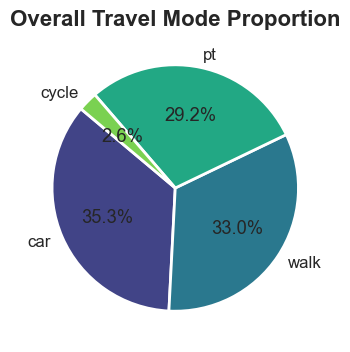

In [38]:
# 1. mode distribution
plt.figure(figsize=(4, 4))
mode_counts = df['mode'].value_counts()
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette("viridis", len(mode_counts)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Overall Travel Mode Proportion', fontsize=16, fontweight='bold')
plt.show()

In [39]:
import pandas as pd
import numpy as np

# 1. 如果该列现在全是 nan，我们需要确保它是字符串类型
# 如果你发现 df['household_income'] 已经彻底丢失数据，请确保之前的加载代码没有 dropna() 掉它
df['household_income'] = df['household_income'].astype(str)

# 2. 定义一个灵活的清洗函数，处理各种符号和空格
def clean_income(val):
    s = str(val).replace('£', '').replace(',', '').strip().lower()
    if 'nan' in s or 'unknown' in s or s == '':
        return 'Unknown'
    
    # 根据关键词映射到你的 10 个分类
    if '100000' in s: return '>100000'
    if '75000' in s: return '75000-99999'
    if '50000' in s: return '50000-74999'
    if '35000' in s: return '35000-49999'
    if '25000' in s: return '25000-34999'
    if '20000' in s: return '20000-24999'
    if '15000' in s: return '15000-19999'
    if '10000' in s: return '10000-14999'
    if '5000' in s: return '5000-9999'
    if 'less than' in s or '0 - 4' in s or 'under' in s: return '<5000'
    
    return 'Unknown'

# 执行清洗映射
df['household_income'] = df['household_income'].apply(clean_income)

# 3. 重新设置为有序分类
income_order_final = ['<5000', '5000-9999', '10000-14999', '15000-19999', 
                      '20000-24999', '25000-34999', '35000-49999', 
                      '50000-74999', '75000-99999', '>100000', 'Unknown']

df['household_income'] = pd.Categorical(df['household_income'], 
                                        categories=income_order_final, 
                                        ordered=True)

# 检查结果：如果这里全是 0，说明原始数据源确实没加载进来
print("清洗后的分布情况：")
print(df['household_income'].value_counts())

清洗后的分布情况：
household_income
50000-74999    35174
>100000        33091
35000-49999    32985
25000-34999    25936
5000-9999      22663
75000-99999    20724
10000-14999    16917
20000-24999    16540
15000-19999    16153
<5000              0
Unknown            0
Name: count, dtype: int64


/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_19690/1867728489.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['household_income'] = pd.Categorical(df['household_income'], categories=income_order, ordered=True)
/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_19690/1867728489.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)


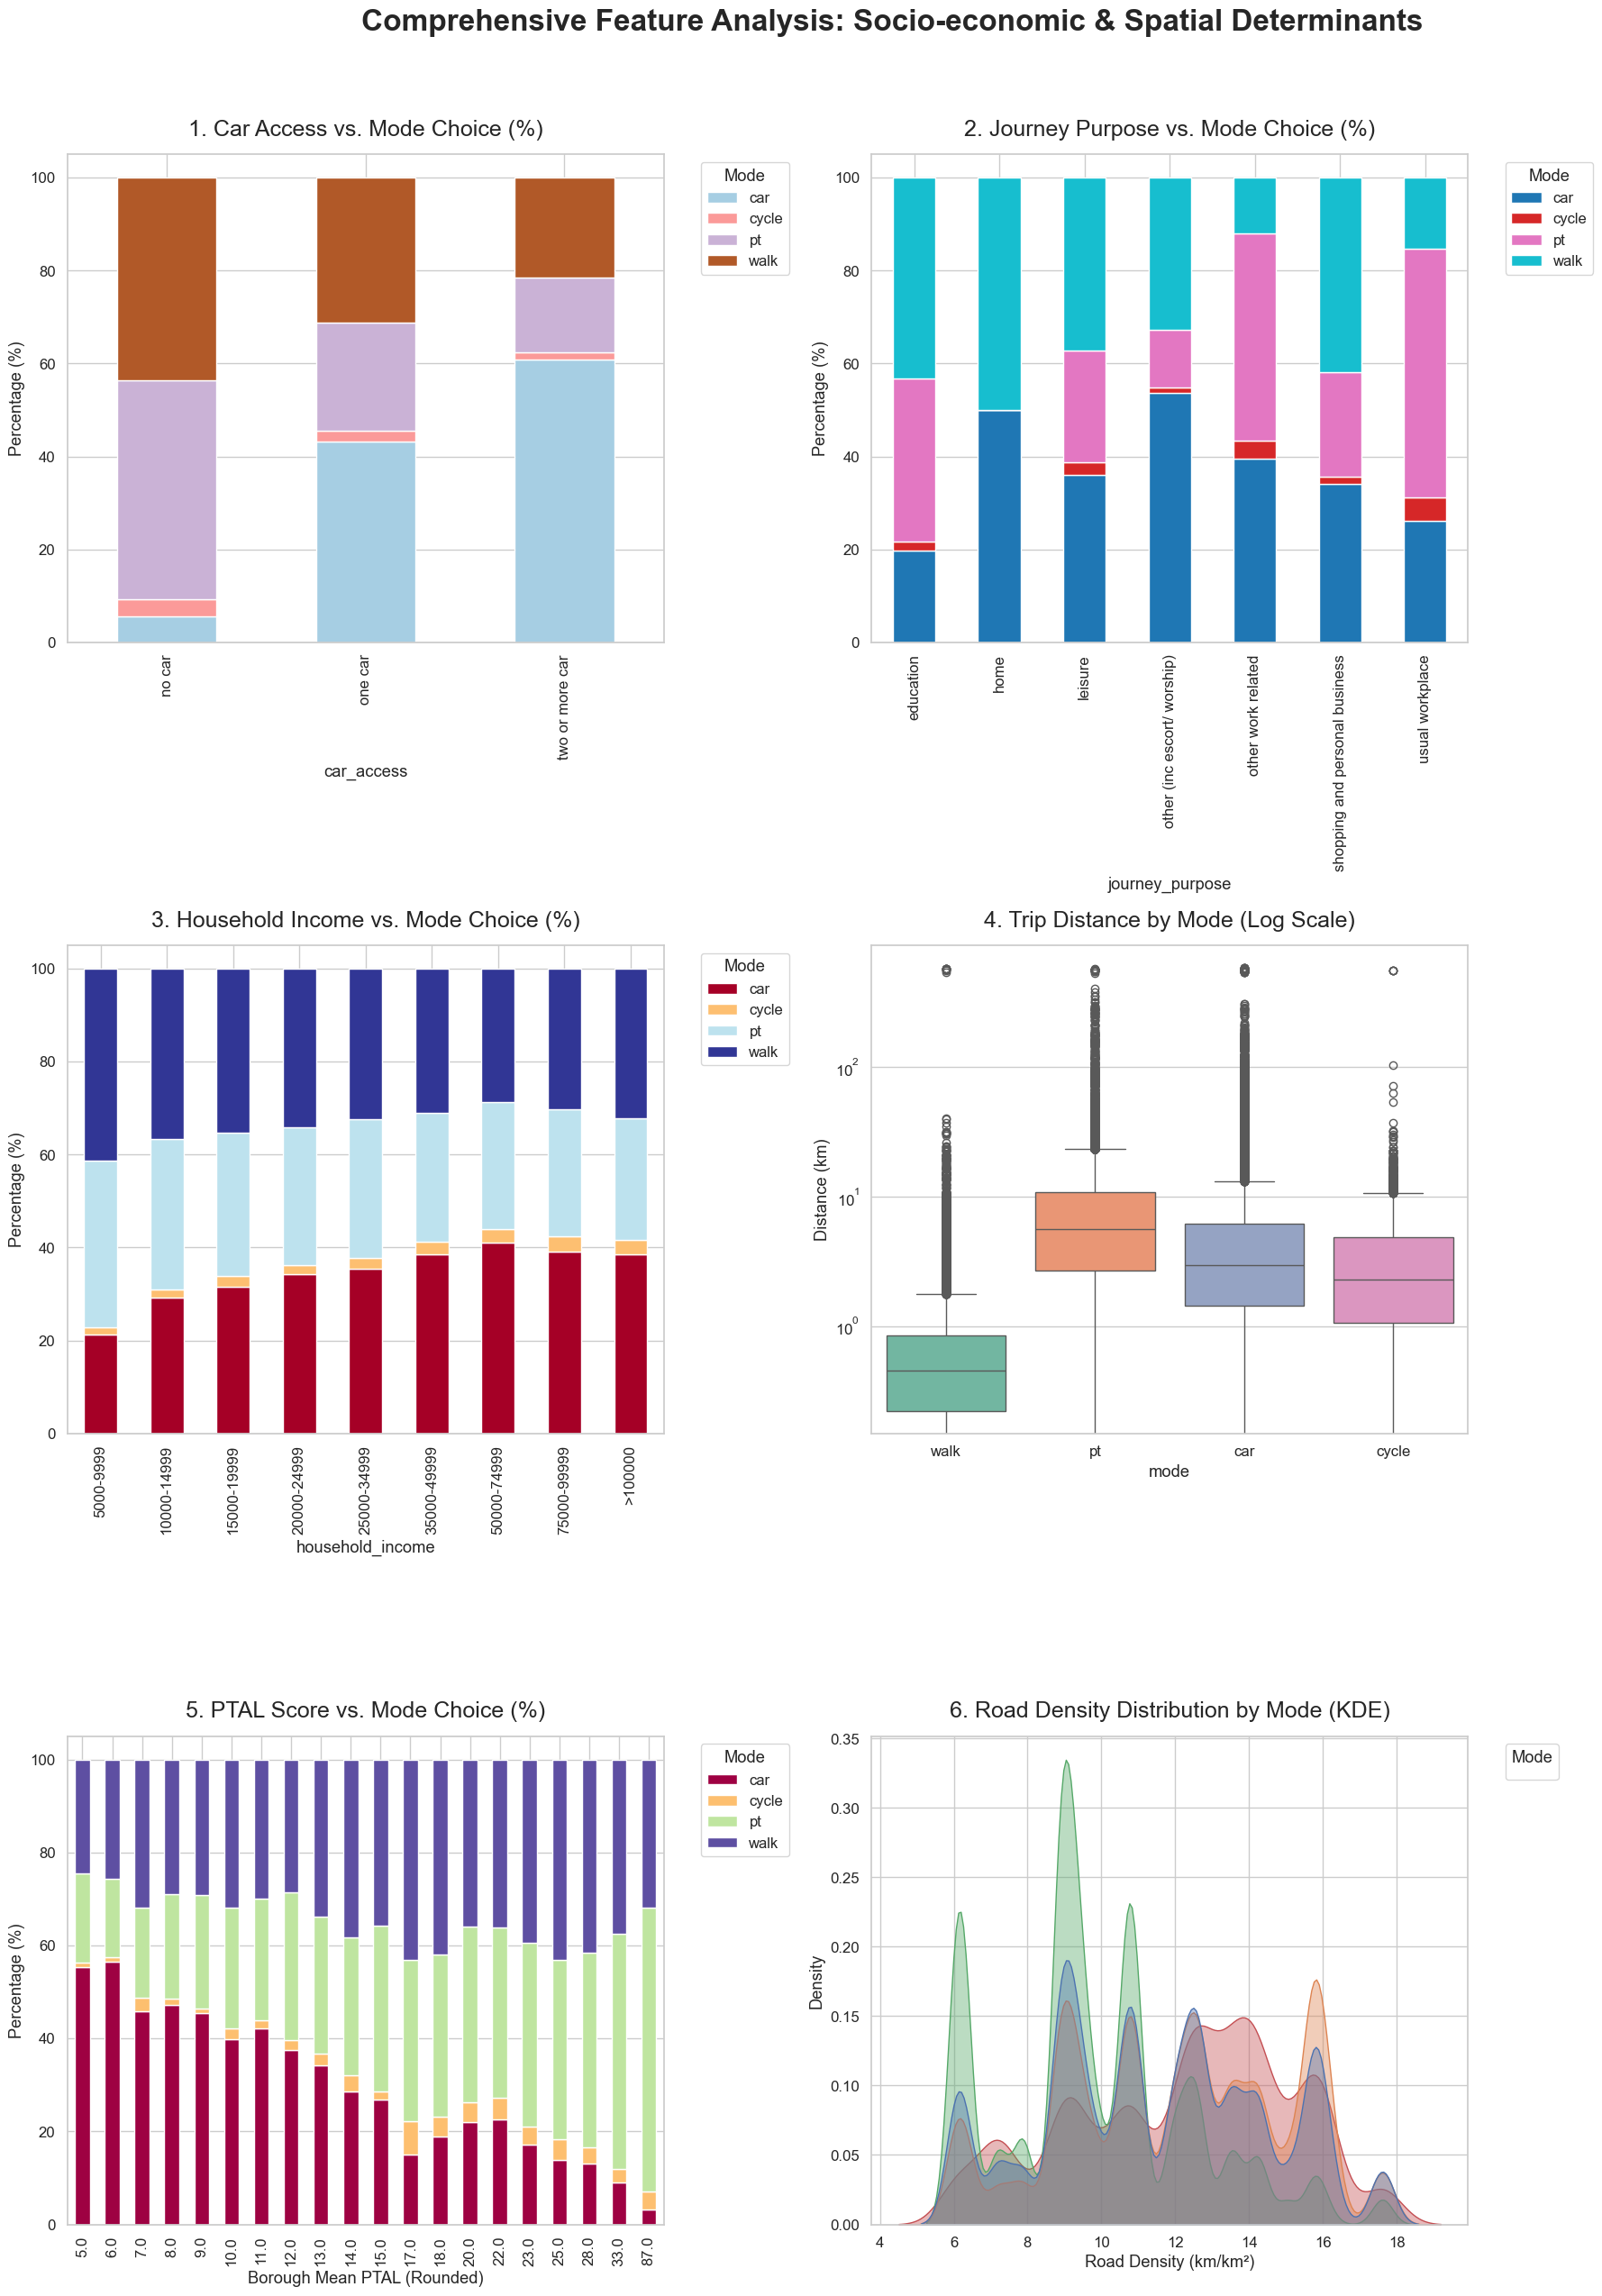

In [41]:
# 1. 风格与基础配置
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'

# 2. 收入顺序预设 (防止排序混乱)
income_order = ['5000-9999', '10000-14999', '15000-19999', '20000-24999', 
                '25000-34999', '35000-49999', '50000-74999', '75000-99999', '>100000']
df['household_income'] = pd.Categorical(df['household_income'], categories=income_order, ordered=True)

# 3. 创建画布：3行2列
fig, axes = plt.subplots(3, 2, figsize=(20, 26))
fig.suptitle('Comprehensive Feature Analysis: Socio-economic & Spatial Determinants', fontsize=24, fontweight='bold', y=0.98)

# --- 第一行：核心预测因子 ---
# (0,0) Car Access
car_cross = pd.crosstab(df['car_access'], df['mode'], normalize='index') * 100
car_cross.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='Paired', edgecolor='white')
axes[0, 0].set_title('1. Car Access vs. Mode Choice (%)', fontsize=18, pad=15)
axes[0, 0].set_ylabel('Percentage (%)')

# (0,1) Journey Purpose
purpose_cross = pd.crosstab(df['journey_purpose'], df['mode'], normalize='index') * 100
purpose_cross.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='tab10', edgecolor='white')
axes[0, 1].set_title('2. Journey Purpose vs. Mode Choice (%)', fontsize=18, pad=15)
axes[0, 1].set_ylabel('Percentage (%)')


# --- 第二行：经济与物理约束 ---
# (1,0) Household Income
income_cross = pd.crosstab(df['household_income'], df['mode'], normalize='index') * 100
income_cross.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='RdYlBu', edgecolor='white')
axes[1, 0].set_title('3. Household Income vs. Mode Choice (%)', fontsize=18, pad=15)
axes[1, 0].set_ylabel('Percentage (%)')

# (1,1) Trip Distance (Boxplot)
sns.boxplot(data=df, x='mode', y='distance_(km)', ax=axes[1, 1], palette='Set2', hue='mode', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('4. Trip Distance by Mode (Log Scale)', fontsize=18, pad=15)
axes[1, 1].set_ylabel('Distance (km)')


# --- 第三行：建成环境特征 ---
# (2,0) PTAL Score
if 'borough_mean_ptal' in df.columns:
    ptal_cross = pd.crosstab(df['borough_mean_ptal'].round(), df['mode'], normalize='index') * 100
    ptal_cross.plot(kind='bar', stacked=True, ax=axes[2, 0], colormap='Spectral', edgecolor='white')
    axes[2, 0].set_title('5. PTAL Score vs. Mode Choice (%)', fontsize=18, pad=15)
    axes[2, 0].set_xlabel('Borough Mean PTAL (Rounded)')
    axes[2, 0].set_ylabel('Percentage (%)')

# (2,1) Road Density (KDE)
if 'road_density' in df.columns:
    sns.kdeplot(data=df, x='road_density', hue='mode', fill=True, common_norm=False, ax=axes[2, 1], alpha=0.4)
    axes[2, 1].set_title('6. Road Density Distribution by Mode (KDE)', fontsize=18, pad=15)
    axes[2, 1].set_xlabel('Road Density (km/km²)')

# --- 统一调整图例和布局 ---
for ax in axes.flat:
    if ax.get_legend():
        ax.legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

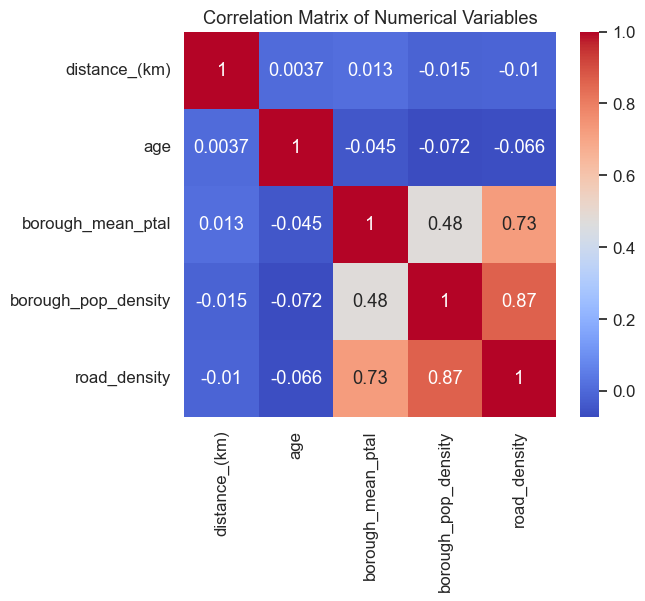

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['distance_(km)', 'age', 'borough_mean_ptal', 
            'borough_pop_density', 'road_density']

corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_19690/1801408013.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_19690/1801408013.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this w

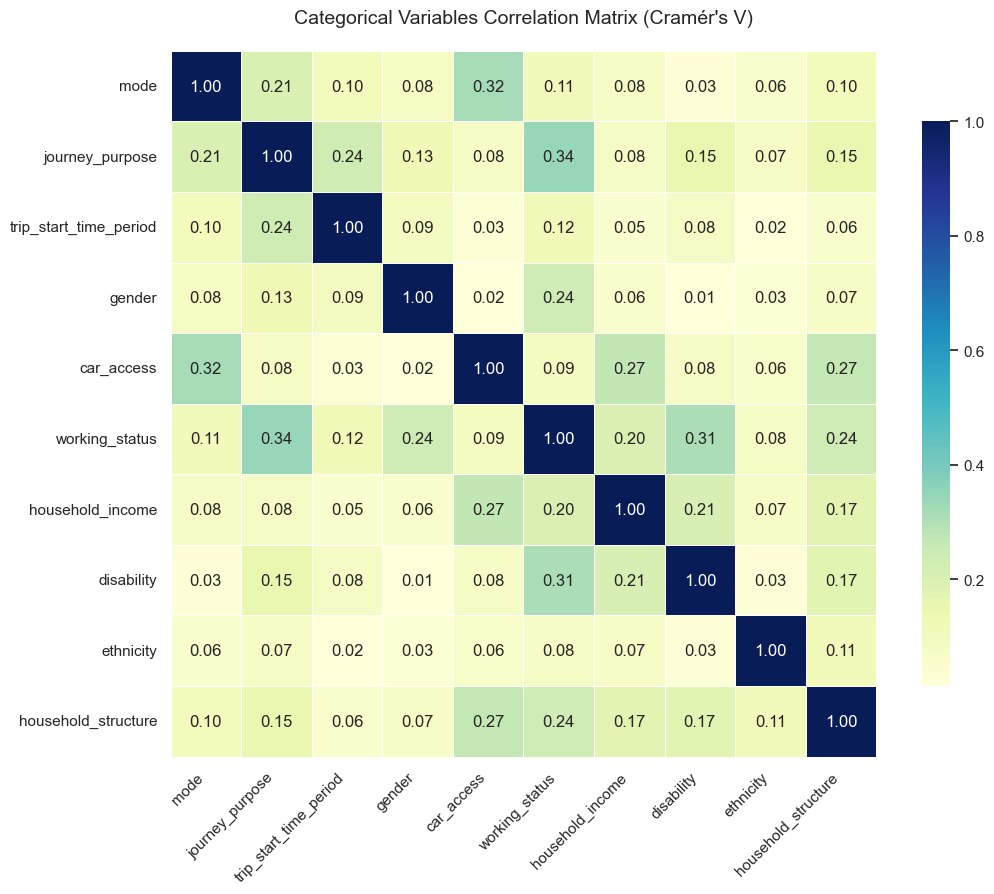

In [45]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Ensure cat_cols is defined (excluding columns you already dropped)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Initialize matrix
v_matrix = np.zeros((len(cat_cols), len(cat_cols)))

# 1. 筛选变量并排除
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'origin_borough' in cat_cols:
    cat_cols.remove('origin_borough')

# 2. 计算矩阵 (复用之前的逻辑)
v_matrix = np.zeros((len(cat_cols), len(cat_cols)))
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        v_matrix[i, j] = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
df_v = pd.DataFrame(v_matrix, index=cat_cols, columns=cat_cols)

# 3. 绘图 - 这里更换了配色和风格
plt.figure(figsize=(11, 9))
sns.set_theme(style="white") # 设置白色背景背景

# 使用 'YlGnBu' 配色，并添加了一些细节美化
sns.heatmap(df_v, 
            annot=True, 
            fmt='.2f', 
            cmap='YlGnBu',  # 🔥 在这里更换配色：'YlGnBu', 'rocket_r', 'mako', 'viridis'
            linewidths=.5,  # 格子间的白线，增加精致感
            cbar_kws={"shrink": .8}, # 缩放侧边颜色条
            square=True)    # 强制格子为正方形

plt.title("Categorical Variables Correlation Matrix (Cramér's V)", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right') # 标签倾斜，防止重叠
plt.tight_layout()
plt.show()

In [46]:
df.head()



,mode,distance_(km),journey_purpose,trip_start_time_period,gender,age,car_access,working_status,household_income,disability,ethnicity,household_structure,borough_mean_ptal,borough_pop_density,road_density
0,walk,1.07,shopping and personal business,am peak (0700-0959),female,32,no car,not working,10000-14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
1,walk,1.07,shopping and personal business,interpeak (1000-1559),female,32,no car,not working,10000-14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
2,pt,15.19,usual workplace,am peak (0700-0959),male,35,two or more car,full-time worker,75000-99999,not disabled,asian,couple without children,8.42,6530.50,9.59
3,pt,15.19,usual workplace,evening (1900-2159),male,35,two or more car,full-time worker,75000-99999,not disabled,asian,couple without children,25.40,15129.70,15.94
4,pt,15.91,education,am peak (0700-0959),male,55,one car,part-time worker,5000-9999,not disabled,asian,lone parent,8.42,6530.50,9.59


划分数据集

In [49]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
exclude_cols = ['unique_trip_id', 'year', 'mode', 'origin_borough']
X = df.drop(columns=[col for col in exclude_cols if col in df.columns]) 
y = df['mode']

# 2. First split: 70% Training, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3. Second split: 50% of Temporary set (15% of total) for Validation and Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- Verification ---
print("Data partitioning completed:")
print(f"Train Set: {X_train.shape[0]} rows")
print(f"Val Set:   {X_val.shape[0]} rows")
print(f"Test Set:  {X_test.shape[0]} rows")
print(f"\nCurrent feature list: {X.columns.tolist()}")

Data partitioning completed:
Train Set: 154128 rows
Val Set:   33027 rows
Test Set:  33028 rows

Current feature list: ['distance_(km)', 'journey_purpose', 'trip_start_time_period', 'gender', 'age', 'car_access', 'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure', 'borough_mean_ptal', 'borough_pop_density', 'road_density']


smote

In [53]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# 1. Define variable classifications
cat_features = ['journey_purpose', 'trip_start_time_period', 'gender', 'car_access', 
                'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure']
num_features = ['distance_(km)', 'age', 'borough_mean_ptal', 'borough_pop_density', 'road_density']

# 2. Label Encoding for categorical features (Required for SMOTE and Set A)
X_train_le = X_train.copy()
X_val_le = X_val.copy()
X_test_le = X_test.copy()

for col in cat_features:
    le = LabelEncoder()
    # Apply fit_transform on training and transform on val/test to prevent leakage
    X_train_le[col] = le.fit_transform(X_train[col].astype(str))
    X_val_le[col] = le.transform(X_val[col].astype(str))
    X_test_le[col] = le.transform(X_test[col].astype(str))

# 2.1 Label Encoding for target variable y (Fixes the NameError)
le_y = LabelEncoder()
y_train_le = le_y.fit_transform(y_train)
y_val_le = le_y.transform(y_val)
y_test_le = le_y.transform(y_test)

# 3. SMOTE Resampling (Apply only to training set to handle class imbalance)
print("Executing SMOTE to balance the training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_le, y_train_le)

# 4. Construct Multi-path Datasets

# --- Set A: Optimized for Tree-based Models (XGBoost/RF) ---
# Uses Label Encoded features directly from the resampled training data
X_train_set_A = X_train_res
y_train_set_A = y_train_res
X_val_set_A = X_val_le
X_test_set_A = X_test_le

# --- Set B: Optimized for Neural Networks (One-hot + Scaling) ---
# Scale numerical features
scaler = StandardScaler()
num_train_sc = scaler.fit_transform(X_train_res[num_features])
num_val_sc = scaler.transform(X_val_le[num_features])
num_test_sc = scaler.transform(X_test_le[num_features])

# Convert Label Encoded categories to One-hot vectors
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_train_ohe = ohe.fit_transform(X_train_res[cat_features])
cat_val_ohe = ohe.transform(X_val_le[cat_features])
cat_test_ohe = ohe.transform(X_test_le[cat_features])

# Horizontally stack numerical and categorical arrays
X_train_set_B = np.hstack([num_train_sc, cat_train_ohe])
X_val_set_B = np.hstack([num_val_sc, cat_val_ohe])
X_test_set_B = np.hstack([num_test_sc, cat_test_ohe])

# 5. Output summary of the prepared data
print("\n--- Data Engineering Summary ---")
print(f"Original Training samples: {len(X_train)}")
print(f"Resampled Training samples (SMOTE): {len(X_train_res)}")
print(f"Set A feature count: {X_train_set_A.shape[1]}")
print(f"Set B feature count (One-hot expanded): {X_train_set_B.shape[1]}")

Executing SMOTE to balance the training set...

--- Data Engineering Summary ---
Original Training samples: 154128
Resampled Training samples (SMOTE): 217572
Set A feature count: 14
Set B feature count (One-hot expanded): 51


In [73]:
import numpy as np
import pandas as pd
from tensorflow.keras.layers import Input, Embedding, Reshape, Concatenate, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Variable Re-classification
# ==========================================
# Move 'age' from num_features to cat_features
cat_to_embed = ['journey_purpose', 'trip_start_time_period', 'gender', 'car_access', 
                'working_status', 'household_income', 'disability', 'ethnicity', 
                'household_structure', 'age'] # age is now here

# Update numerical features (remove age)
num_to_keep = ['distance_(km)', 'borough_mean_ptal', 'borough_pop_density', 'road_density']

# ==========================================
# 2. Ladder Dimension Logic (3-6-10 Rule)
# ==========================================
def get_ladder_dim(vocab_size):
    v = vocab_size - 1
    if v <= 3:
        return 1
    elif v <= 6:
        return 3
    elif v <= 10:
        return 6
    else:
        return 10 # Age usually has > 10 unique values, so it gets 10 dims

# ==========================================
# 3. Build Refined Ladder Model
# ==========================================
def build_refined_ladder_model(cat_list, num_list, num_classes):
    all_inputs, all_embeddings = [], []

    # Categorical Feature Processing (Including Age)
    for col in cat_list:
        vocab_size = X_train_res[col].nunique() + 1
        emb_dim = get_ladder_dim(vocab_size)
        
        in_layer = Input(shape=(1,), name=f"input_{col}")
        emb_layer = Embedding(vocab_size, emb_dim, name=f"emb_{col}")(in_layer)
        emb_layer = Reshape(target_shape=(emb_dim,))(emb_layer)
        
        all_inputs.append(in_layer)
        all_embeddings.append(emb_layer)
        print(f"Embedding: {col:<22} | Values: {vocab_size-1:<3} | Dim: {emb_dim}")

    # Numerical Feature Connection
    # Note: Use the updated num_to_keep and corresponding scaled arrays
    if num_list:
        in_num = Input(shape=(len(num_list),), name="input_numerical")
        all_inputs.append(in_num)
        all_embeddings.append(in_num)
        print(f"Numerical: {num_list} | Dim: {len(num_list)}")

    x = Concatenate(name="set_c_concat")(all_embeddings)

    # DNN Layers
    x_dense = Dense(256, activation='relu')(x)
    x_dense = BatchNormalization()(x_dense)
    x_dense = Dropout(0.3)(x_dense)
    
    for _ in range(4):
        x_dense = Dense(256, activation='relu')(x_dense)
        x_dense = BatchNormalization()(x_dense)
        x_dense = Dropout(0.3)(x_dense)

    x_dense = Dense(128, activation='relu')(x_dense)
    x_dense = BatchNormalization()(x_dense)
    x_dense = Dropout(0.3)(x_dense)

    output = Dense(num_classes, activation='softmax')(x_dense)
    return Model(inputs=all_inputs, outputs=output)

# ==========================================
# 4. Data Preparation (Crucial Update)
# ==========================================

# num_train_final = X_train_res[num_to_keep].values # or use your scaled version
num_train_final = scaler.fit_transform(X_train_res[num_to_keep])
num_val_final = scaler.transform(X_val_le[num_to_keep])
num_test_final = scaler.transform(X_test_le[num_to_keep])

X_train_inputs = [X_train_res[col].values for col in cat_to_embed] + [num_train_final]
X_val_inputs = [X_val_le[col].values for col in cat_to_embed] + [num_val_final]
X_test_inputs = [X_test_le[col].values for col in cat_to_embed] + [num_test_final]

# Train and Extract
num_classes = len(np.unique(y_train_res))
final_model = build_refined_ladder_model(cat_to_embed, num_to_keep, num_classes)
final_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

final_model.fit(
    X_train_inputs, y_train_res,
    epochs=100, batch_size=2048,
    validation_data=(X_val_inputs, y_val_le),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
    ],
    verbose=1
)

# Extract Set C
feature_extractor = Model(inputs=final_model.input, outputs=final_model.get_layer('set_c_concat').output)
X_train_C = feature_extractor.predict(X_train_inputs, batch_size=4096)
X_val_C = feature_extractor.predict(X_val_inputs, batch_size=4096)
X_test_C = feature_extractor.predict(X_test_inputs, batch_size=4096)

print(f"\nFinal Set C Dimension: {X_train_C.shape[1]}")

Embedding: journey_purpose        | Values: 7   | Dim: 6
Embedding: trip_start_time_period | Values: 6   | Dim: 3
Embedding: gender                 | Values: 2   | Dim: 1
Embedding: car_access             | Values: 3   | Dim: 1
Embedding: working_status         | Values: 6   | Dim: 3
Embedding: household_income       | Values: 9   | Dim: 6
Embedding: disability             | Values: 2   | Dim: 1
Embedding: ethnicity              | Values: 5   | Dim: 3
Embedding: household_structure    | Values: 6   | Dim: 3
Embedding: age                    | Values: 95  | Dim: 10
Numerical: ['distance_(km)', 'borough_mean_ptal', 'borough_pop_density', 'road_density'] | Dim: 4
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.4205 - loss: 1.3397 - val_accuracy: 0.5741 - val_loss: 1.1020 - learning_rate: 0.0010
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5115 - loss: 1.1487 - val_accuracy: 0.5710 - val_loss: 1.1868 - learning_rate: 0.0010
Epoch 3/100
107/107 ━━

Table: Categorical Variables and Entity Embedding Dimensions

| Variable Name | Type | Number of Values | Dimension |
| :--- | :--- | :---: | :---: |
| journey_purpose | nominal | 5 | 3 |
| trip_start_time_period | nominal | 4 | 3 |
| gender | binary | 2 | 1 |
| car_access | nominal | 4 | 3 |
| working_status | nominal | 6 | 3 |
| household_income | ordinal | 9 | 6 |
| disability | binary | 2 | 1 |
| ethnicity | nominal | 5 | 3 |
| household_structure | nominal | 7 | 6 |
| age | ordinal | 91 | 10 |
| **Total Embedding Dimensions** | - | - | **39** |

> **Note**: The embedding dimensions are assigned using a ladder logic (3-6-10 rule) to balance model complexity and feature representational power. Variables with more than 10 unique values (like `age`) are compressed into a 10-dimensional latent space.

Table: Categorical Variables and Entity Embedding Dimensions

| Variable Name | Type | Number of Values | Dimension |
| :--- | :--- | :---: | :---: |
| journey_purpose | nominal | 7 | 6 |
| trip_start_time_period | nominal | 6 | 3 |
| gender | binary | 2 | 1 |
| car_access | nominal | 3 | 1 |
| working_status | nominal | 6 | 3 |
| household_income | ordinal | 9 | 6 |
| disability | binary | 2 | 1 |
| ethnicity | nominal | 5 | 3 |
| household_structure | nominal | 6 | 3 |
| age | ordinal | 95 | 10 |
| **Total Embedding Dimensions** | - | - | **37** |

> **Note**: Embedding dimensions are dynamically assigned based on the unique value count (Vocabulary Size) of each categorical feature, following the defined 3-6-10 ladder logic.

random search setc

全局变量存储

In [76]:
import pandas as pd
import numpy as np

# Global containers for final 3x3 plots and summary tables
all_results = {}      # To store metrics (Accuracy, Kappa, etc.)
all_preds = {}        # To store predicted labels (for Confusion Matrices)
all_probs = {}        # To store predicted probabilities (for ROC Curves)
all_best_params = {}  # To store the optimal hyperparameter sets

# Unified naming convention for the three data scenarios
SET_NAMES = ['Set A', 'Set B', 'Set C']

In [77]:
from sklearn.metrics import (accuracy_score, cohen_kappa_score, log_loss, 
                             classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def full_evaluate_model(model, X_val, y_val, classes, model_name="Model"):
    # 1. Get the forecast results
    if hasattr(model, 'predict_proba'):
        # scikit-learn 
        y_prob = model.predict_proba(X_val)
        y_pred = model.predict(X_val)
    else:
        # Keras models – `predict()` returns probabilities
        y_prob = model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
    
    # 2. ACC, NLL, CK
    acc = accuracy_score(y_val, y_pred)
    nll = log_loss(y_val, y_prob)
    ck = cohen_kappa_score(y_val, y_pred)
    
    # 3.  G-Mean 
    cm = confusion_matrix(y_val, y_pred)
    recalls = np.diag(cm) / (cm.sum(axis=1) + 1e-9)
    g_mean = np.exp(np.mean(np.log(recalls + 1e-9)))
    
    print(f"\n" + "="*40)
    print(f" {model_name} Final Evaluation Report")
    print("="*40)
    print(f"1. Accuracy (ACC):         {acc:.4f}")
    print(f"2. Neg Log Likelihood (NLL): {nll:.4f}")
    print(f"3. Cohen's Kappa (CK):      {ck:.4f}")
    print(f"4. Geometric Mean (G-Mean):  {g_mean:.4f}")
    
    # 4. Plotting a confusion matrix
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # 5. ROC 
    plt.subplot(1, 2, 2)
    y_val_bin = label_binarize(y_val, classes=range(len(classes)))
    n_classes = len(classes)
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f'ROC Curves: {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    return {"ACC": acc, "NLL": nll, "CK": ck, "G-Mean": g_mean}

rf 


 Currently optimising and training: Set A

 Set A Final Evaluation Report
1. Accuracy (ACC):         0.8134
2. Neg Log Likelihood (NLL): 0.5364
3. Cohen's Kappa (CK):      0.7267
4. Geometric Mean (G-Mean):  0.6967


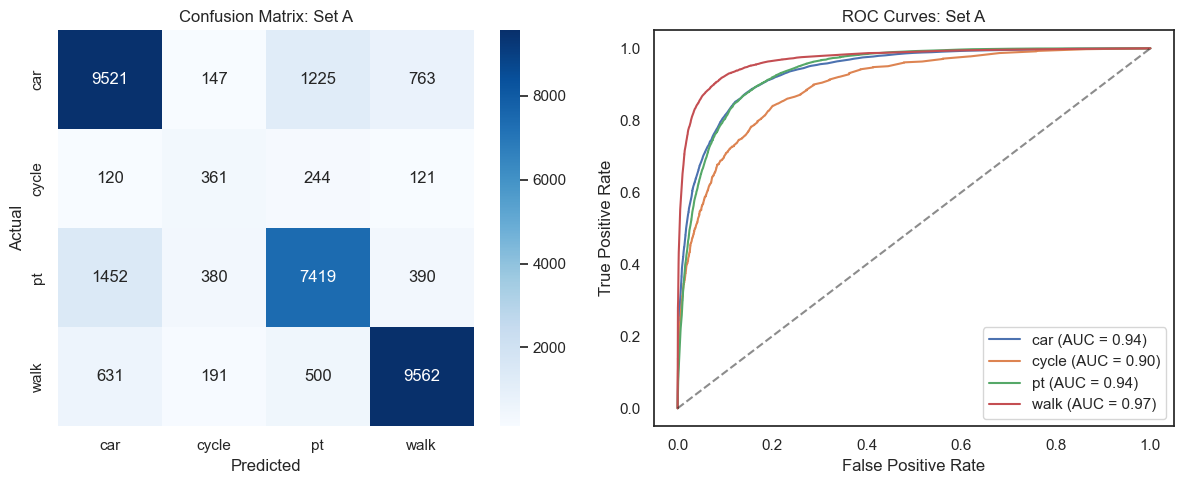


 Currently optimising and training: Set B

 Set B Final Evaluation Report
1. Accuracy (ACC):         0.8071
2. Neg Log Likelihood (NLL): 0.5411
3. Cohen's Kappa (CK):      0.7179
4. Geometric Mean (G-Mean):  0.6870


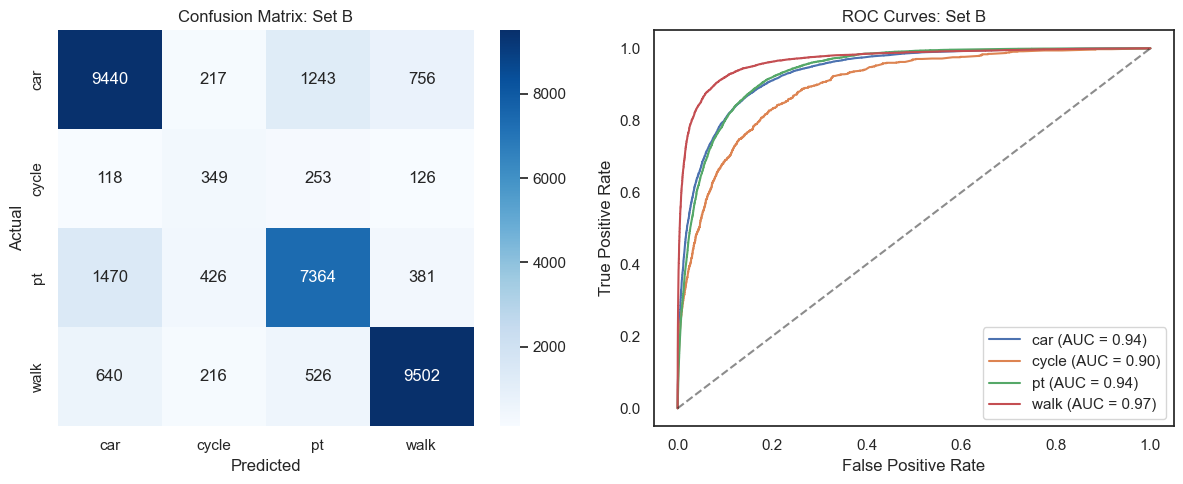


 Currently optimising and training: Set C

 Set C Final Evaluation Report
1. Accuracy (ACC):         0.8166
2. Neg Log Likelihood (NLL): 0.5357
3. Cohen's Kappa (CK):      0.7319
4. Geometric Mean (G-Mean):  0.7164


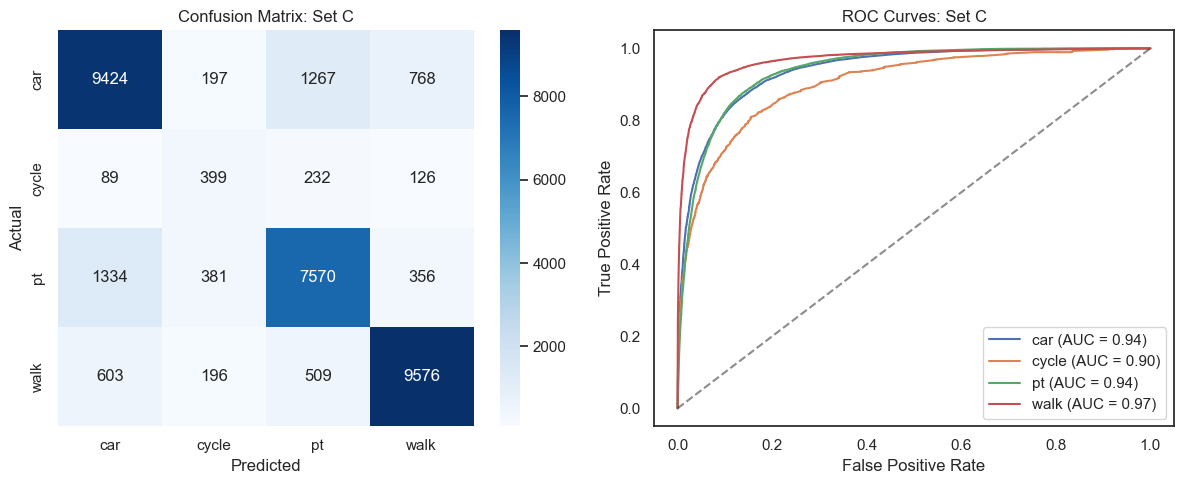


 Final Experiment Summary Table (Summary Table) 
 Scenario    ACC    NLL     CK  G-Mean
 RF_Set A 0.8134 0.5364 0.7267  0.6967
 RF_Set B 0.8071 0.5411 0.7179  0.6870
 RF_Set C 0.8166 0.5357 0.7319  0.7164
XGB_Set A 0.8266 0.4880 0.7459  0.7100
XGB_Set B 0.8261 0.4824 0.7455  0.7124
XGB_Set C 0.8280 0.4873 0.7485  0.7322
DNN_Set A 0.5794 1.0682 0.3773  0.3865
DNN_Set B 0.6474 0.8843 0.4979  0.5411
DNN_Set C 0.6510 0.8611 0.4996  0.5376


In [96]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. 完善参数空间（基于 SMOTE 平衡后的逻辑）
param_dist = {
    'max_depth': [15, 30],
    'n_estimators': [100, 200],
    'class_weight': [ None, 'balanced'],
    'max_features': ['sqrt', 'log2']
}

# 2. 定义数据字典，方便循环处理
scenarios = {
    'Set A': (X_train_set_A, X_val_set_A),
    'Set B': (X_train_set_B, X_val_set_B),
    'Set C': (X_train_C, X_val_C)
}

for name in SET_NAMES:
    X_train_current, X_val_current = scenarios[name]
    
    print(f"\n Currently optimising and training: {name}")
    
    # Perform a random search
    rs = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=8, cv=3, scoring='accuracy', random_state=42, verbose=0
    )
    
    # Fitting the model
    rs.fit(X_train_current, y_train_res)
    best_model = rs.best_estimator_
    
    # --- 调用你定义的评估函数 ---
    metrics = full_evaluate_model(
        best_model, X_val_current, y_val_le, 
        classes=le_y.classes_, model_name=name
    )
    
    # --- 将数据存入你的全局容器 ---
    unique_key = f"RF_{name}" 
    all_results[unique_key] = metrics
    all_best_params[unique_key] = rs.best_params_
    all_probs[unique_key] = best_model.predict_proba(X_val_current)
    all_preds[unique_key] = best_model.predict(X_val_current)

# --- 3. 生成最终汇总大表 ---
final_comparison = pd.DataFrame.from_dict(all_results, orient='index')

# 整理格式
final_comparison.index.name = 'Scenario'
final_comparison.reset_index(inplace=True)

print("\n" + "="*60)
print(" Final Experiment Summary Table (Summary Table) ")
print("="*60)
print(final_comparison.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))

xgboost

 Starting XGBoost Competition across all Sets...

[XGBoost] Currently optimising and training: Set A

 XGBoost_Set A Final Evaluation Report
1. Accuracy (ACC):         0.8266
2. Neg Log Likelihood (NLL): 0.4880
3. Cohen's Kappa (CK):      0.7459
4. Geometric Mean (G-Mean):  0.7100


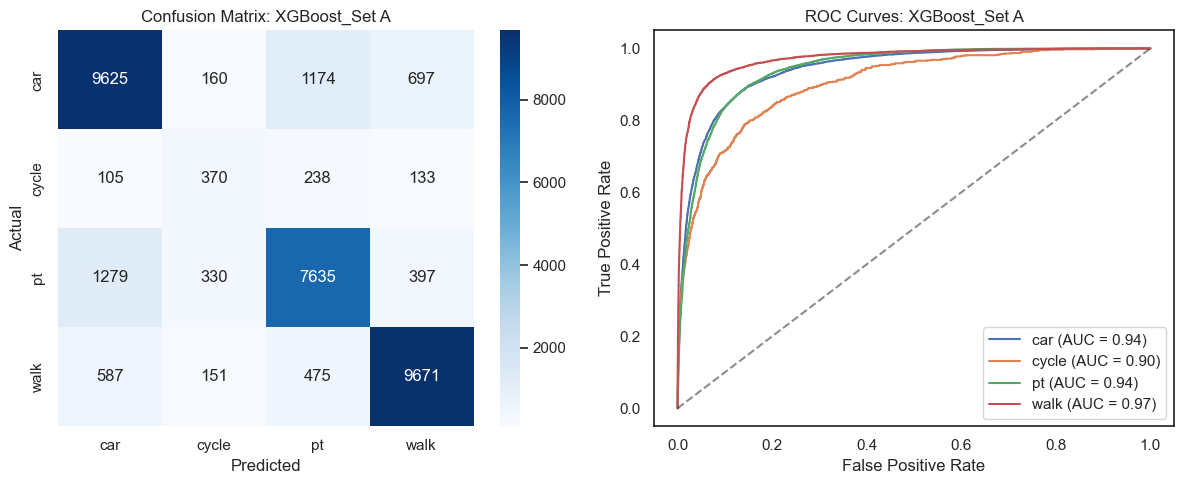


[XGBoost] Currently optimising and training: Set B

 XGBoost_Set B Final Evaluation Report
1. Accuracy (ACC):         0.8261
2. Neg Log Likelihood (NLL): 0.4824
3. Cohen's Kappa (CK):      0.7455
4. Geometric Mean (G-Mean):  0.7124


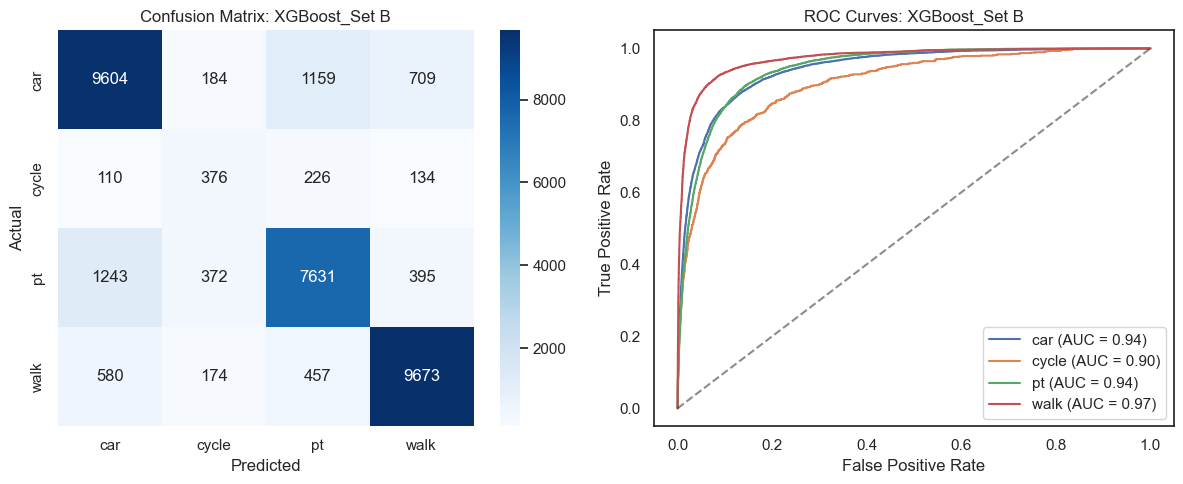


[XGBoost] Currently optimising and training: Set C

 XGBoost_Set C Final Evaluation Report
1. Accuracy (ACC):         0.8280
2. Neg Log Likelihood (NLL): 0.4873
3. Cohen's Kappa (CK):      0.7485
4. Geometric Mean (G-Mean):  0.7322


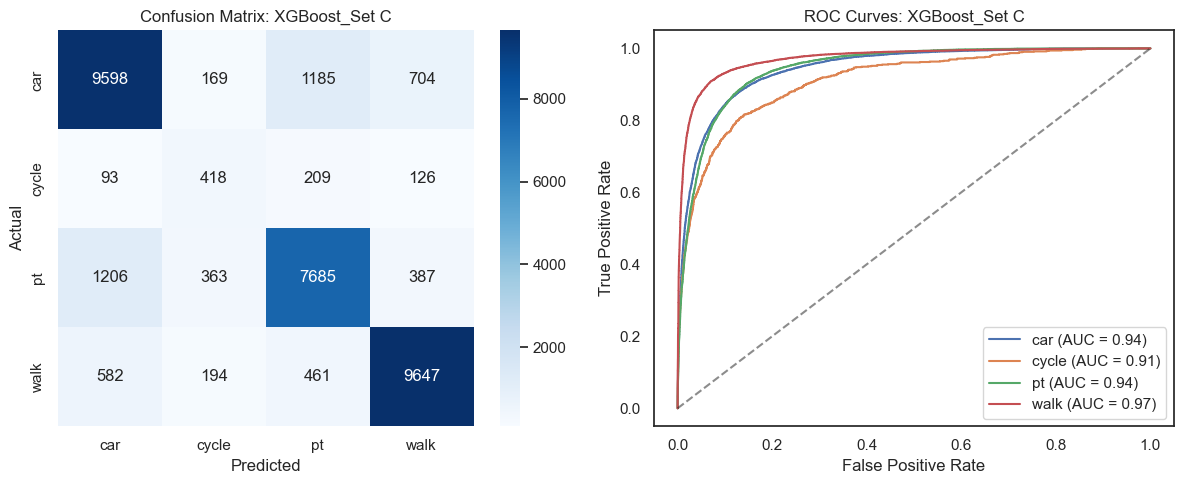


 XGBOOST FINAL EXPERIMENT SUMMARY TABLE 
 Scenario    ACC    NLL     CK  G-Mean
 RF_Set A 0.8134 0.5364 0.7267  0.6967
 RF_Set B 0.8071 0.5411 0.7179  0.6870
 RF_Set C 0.8166 0.5357 0.7319  0.7164
XGB_Set A 0.8266 0.4880 0.7459  0.7100
XGB_Set B 0.8261 0.4824 0.7455  0.7124
XGB_Set C 0.8280 0.4873 0.7485  0.7322


In [79]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# 1. Parameter Grid for XGBoost (Aligned with RF structure)
# Note: 'scale_pos_weight' is handled by SMOTE (y_train_res), so we focus on tree complexity
xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 15],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}

# 2. Data dictionary (Identical to RF scenarios)
scenarios = {
    'Set A': (X_train_set_A, X_val_set_A),
    'Set B': (X_train_set_B, X_val_set_B),
    'Set C': (X_train_C, X_val_C)
}

print(" Starting XGBoost Competition across all Sets...")

for name in SET_NAMES:
    X_train_current, X_val_current = scenarios[name]
    
    print(f"\n[XGBoost] Currently optimising and training: {name}")
    
    # Base XGBoost model definition
    base_xgb = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(le_y.classes_),
        tree_method='hist',  # Efficient for large datasets
        random_state=42,
        n_jobs=-1
    )
    
    # Perform Random Search
    rs = RandomizedSearchCV(
        base_xgb,
        param_distributions=xgb_param_dist,
        n_iter=8, 
        cv=3, 
        scoring='accuracy', 
        random_state=42, 
        verbose=0
    )
    
    # Fitting the model using SMOTE-balanced labels
    rs.fit(X_train_current, y_train_res)
    best_model = rs.best_estimator_
    
    # --- Unified Evaluation Function ---
    # This generates the report and populates local plots
    metrics = full_evaluate_model(
        best_model, X_val_current, y_val_le, 
        classes=le_y.classes_, model_name=f"XGBoost_{name}"
    )
    
    # --- Store data into Global Containers (Aligned with RF logic) ---
    unique_key = f"XGB_{name}" 
    
    all_results[unique_key] = metrics
    all_best_params[unique_key] = rs.best_params_
    all_probs[unique_key] = best_model.predict_proba(X_val_current)
    all_preds[unique_key] = best_model.predict(X_val_current)

# --- 3. Generate Final Comparison Table ---
final_comparison_xgb = pd.DataFrame.from_dict(all_results, orient='index')
final_comparison_xgb.index.name = 'Scenario'
final_comparison_xgb.reset_index(inplace=True)

# Formatting output
pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60)
print(" XGBOOST FINAL EXPERIMENT SUMMARY TABLE ")
print("="*60)
print(final_comparison_xgb.to_string(index=False))

 Starting DNN Competition across all Sets...

[DNN] Currently training on: Set A
Epoch 1/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.3305 - loss: 1.4851 - val_accuracy: 0.3385 - val_loss: 1.4973 - learning_rate: 0.0010
Epoch 2/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3576 - loss: 1.3491 - val_accuracy: 0.3841 - val_loss: 1.3238 - learning_rate: 0.0010
Epoch 3/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3917 - loss: 1.2932 - val_accuracy: 0.4386 - val_loss: 1.2709 - learning_rate: 0.0010
Epoch 4/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4101 - loss: 1.2693 - val_accuracy: 0.4775 - val_loss: 1.2522 - learning_rate: 0.0010
Epoch 5/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4172 - loss: 1.2580 - val_accuracy: 0.4456 - val_loss: 1.2761 - learning_rate: 0.0010
Epoch 6/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4194 - loss: 1.2545 - val_accuracy: 0.4252 - val_loss: 1.3307 - learning_rate: 0.

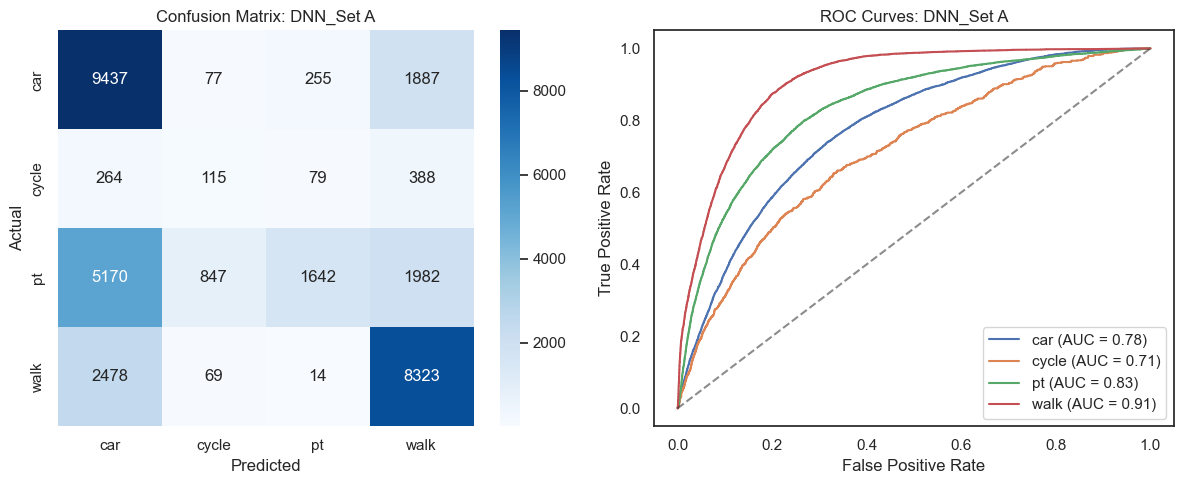

2026-04-26 02:37:25.236095: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: In[0] mismatch In[1] shape: 14 vs. 41: [32,14] [41,256] 0 0
	 [[{{node functional_35_1/dense_135_1/Relu}}]]


InvalidArgumentError: Graph execution error:

Detected at node functional_35_1/dense_135_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/peiyao/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/peiyao/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/peiyao/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/Users/peiyao/Library/Python/3.11/lib/python/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/base_events.py", line 604, in run_forever

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/base_events.py", line 1909, in _run_once

  File "/Library/Frameworks/Python.fra

In [82]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. DNN Architecture Definition
# ==========================================
def build_simple_dnn(input_dim, num_classes, name):
    inputs = Input(shape=(input_dim,), name=f"input_{name}")
    
    x = Dense(256, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=inputs, outputs=outputs, name=f"DNN_{name}")

# ==========================================
# 2. Experimental Loop (Aligned with RF/XGB)
# ==========================================

# Data dictionary (Identical to RF/XGB scenarios)
scenarios = {
    'Set A': (X_train_set_A, X_val_set_A),
    'Set B': (X_train_set_B, X_val_set_B),
    'Set C': (X_train_C, X_val_C)
}

print(" Starting DNN Competition across all Sets...")

for name in SET_NAMES:
    X_train_current, X_val_current = scenarios[name]
    
    print(f"\n[DNN] Currently training on: {name}")
    
    input_dim = X_train_current.shape[1]
    num_classes = len(le_y.classes_)
    
    # Build and Compile
    model = build_simple_dnn(
        input_dim=input_dim,
        num_classes=num_classes,
        name=name.replace(" ", "_")
    )
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Training with EarlyStopping and LR Reduction
    model.fit(
        X_train_current,
        y_train_res,
        validation_data=(X_val_current, y_val_le),
        epochs=100,
        batch_size=1024,  
        verbose=1,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
        ]
    )
    
    # --- Unified Evaluation Function ---
    # This populates the reports and local plots
    metrics = full_evaluate_model(
        model, 
        X_val_current, 
        y_val_le, 
        classes=le_y.classes_, 
        model_name=f"DNN_{name}"
    )
    
    # --- Store data into Global Containers (Aligned with RF/XGB) ---
    unique_key = f"DNN_{name}"
    
    # Evaluate performance
    metrics = full_evaluate_model(
        best_model, X_val_current, y_val_le,  # 这里确保用的是 best_model
        classes=le_y.classes_, model_name=unique_key
    )
    
    # Store into global containers
    all_results[unique_key] = metrics
    all_best_params[unique_key] = best_config
    all_probs[unique_key] = best_model.predict(X_val_current, verbose=0)
    all_preds[unique_key] = np.argmax(all_probs[unique_key], axis=1)


# --- 3. Generate Final Comparison Table ---
final_comparison_dnn = pd.DataFrame.from_dict(all_results, orient='index')
final_comparison_dnn.index.name = 'Scenario'
final_comparison_dnn.reset_index(inplace=True)

# Formatting output
pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60)
print(" DNN FINAL EXPERIMENT SUMMARY TABLE ")
print("="*60)
print(final_comparison_dnn.to_string(index=False))

🚀 开始所有数据集的 DNN 训练与评估...

[DNN] 正在处理场景: Set A | 输入特征维度: 14

 DNN_Set A Final Evaluation Report
1. Accuracy (ACC):         0.5794
2. Neg Log Likelihood (NLL): 1.0682
3. Cohen's Kappa (CK):      0.3773
4. Geometric Mean (G-Mean):  0.3865


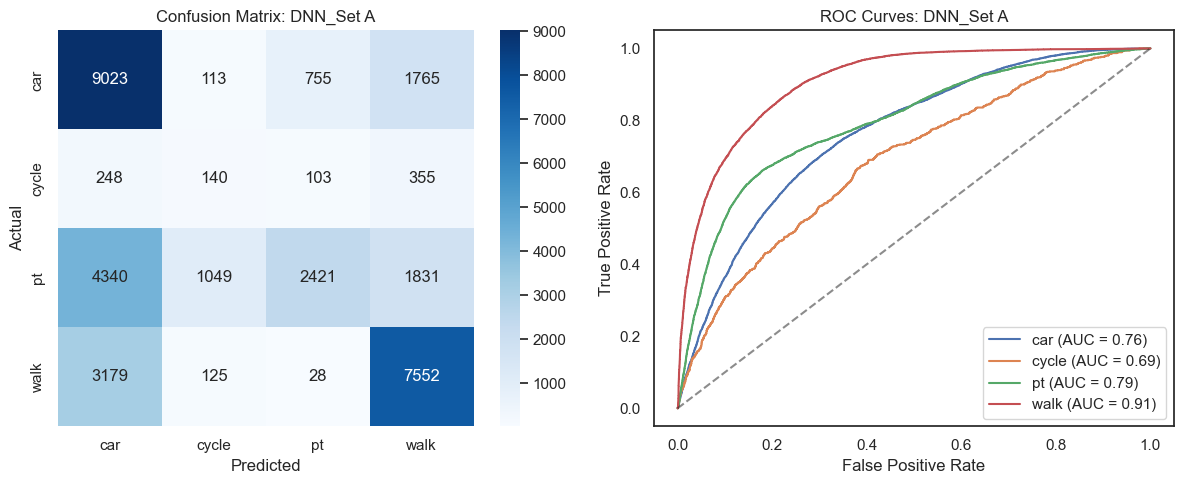


[DNN] 正在处理场景: Set B | 输入特征维度: 51

 DNN_Set B Final Evaluation Report
1. Accuracy (ACC):         0.6474
2. Neg Log Likelihood (NLL): 0.8843
3. Cohen's Kappa (CK):      0.4979
4. Geometric Mean (G-Mean):  0.5411


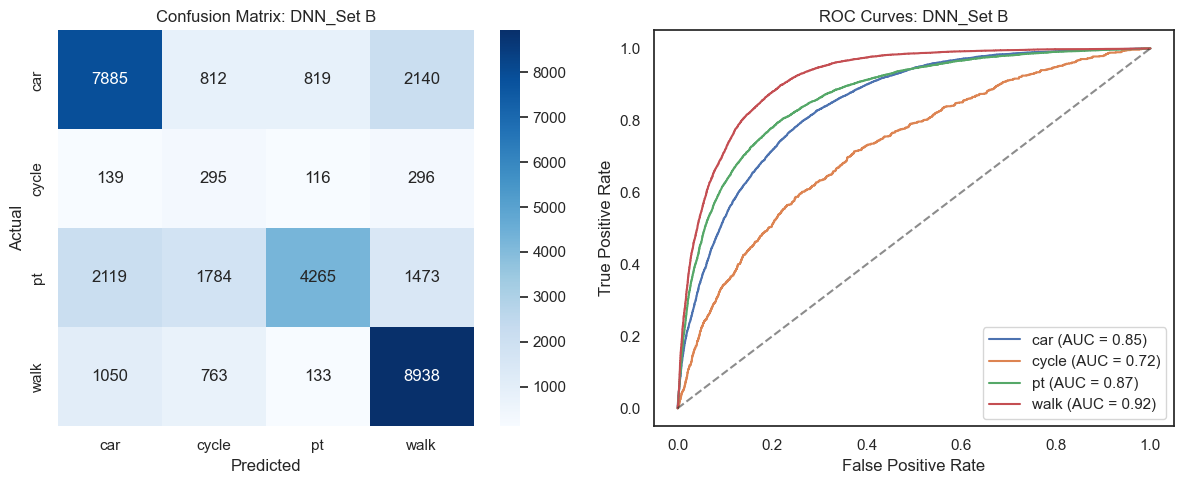


[DNN] 正在处理场景: Set C | 输入特征维度: 41

 DNN_Set C Final Evaluation Report
1. Accuracy (ACC):         0.6510
2. Neg Log Likelihood (NLL): 0.8611
3. Cohen's Kappa (CK):      0.4996
4. Geometric Mean (G-Mean):  0.5376


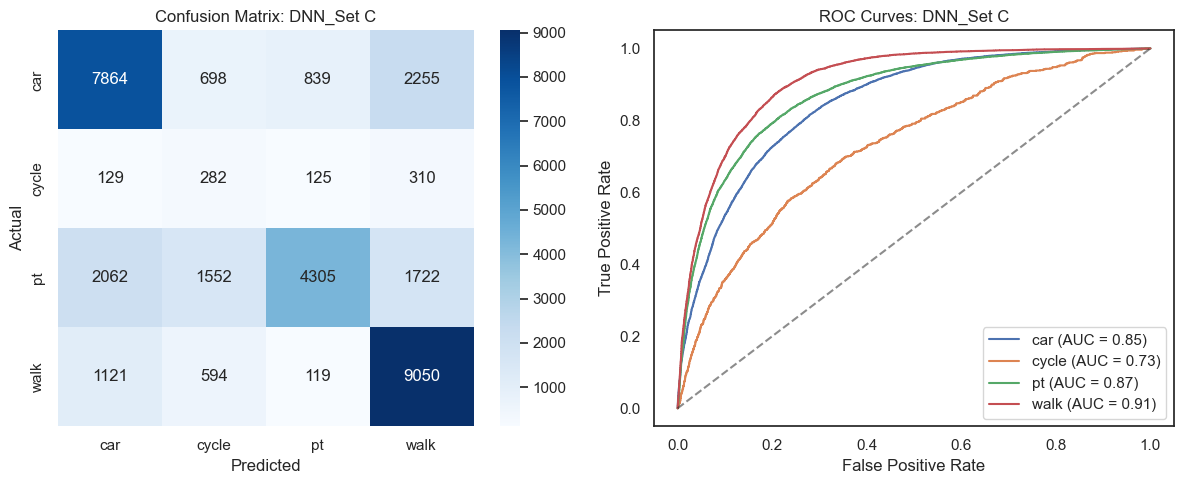


 DNN 最终实验结果汇总表 
 Scenario    ACC    NLL     CK  G-Mean
DNN_Set A 0.5794 1.0682 0.3773  0.3865
DNN_Set B 0.6474 0.8843 0.4979  0.5411
DNN_Set C 0.6510 0.8611 0.4996  0.5376


In [85]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. 动态 DNN 架构定义
# ==========================================
def build_simple_dnn(input_dim, num_classes, name):
    # 根据输入的 input_dim 动态创建输入层
    inputs = Input(shape=(input_dim,), name=f"input_{name}")
    
    x = Dense(256, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=inputs, outputs=outputs, name=f"DNN_{name}")

# ==========================================
# 2. 实验循环（与 RF/XGB 逻辑对齐）
# ==========================================

print("🚀 开始所有数据集的 DNN 训练与评估...")

for name in SET_NAMES:
    # 核心：清除之前的 Keras 会话，防止维度冲突和内存泄漏
    tf.keras.backend.clear_session()
    
    # 获取当前场景的数据
    X_train_current, X_val_current = scenarios[name]
    
    print(f"\n[DNN] 正在处理场景: {name} | 输入特征维度: {X_train_current.shape[1]}")
    
    input_dim = X_train_current.shape[1]
    num_classes = len(le_y.classes_)
    
    # 1. 构建并编译当前模型
    # 注意：这里统一使用 current_dnn 这个变量名
    current_dnn = build_simple_dnn(
        input_dim=input_dim,
        num_classes=num_classes,
        name=name.replace(" ", "_")
    )
    
    current_dnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 2. 模型训练
    current_dnn.fit(
        X_train_current,
        y_train_res,
        validation_data=(X_val_current, y_val_le),
        epochs=100,
        batch_size=1024,  
        verbose=0, # 设置为 1 可查看训练过程
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
        ]
    )
    
    # 3. 统一评估逻辑
    unique_key = f"DNN_{name}"
    
    # 注意：这里必须传入刚刚训练好的 current_dnn
    metrics = full_evaluate_model(
        current_dnn, 
        X_val_current, 
        y_val_le, 
        classes=le_y.classes_, 
        model_name=unique_key
    )
    
    # --- 存储到全局容器（用于后续 3x3 绘图） ---
    all_results[unique_key] = metrics
    all_probs[unique_key] = current_dnn.predict(X_val_current, verbose=0)
    all_preds[unique_key] = np.argmax(all_probs[unique_key], axis=1)
    # 存储基础参数信息
    all_best_params[unique_key] = {"hidden_units": "256-128", "learning_rate": 0.001}

# ==========================================
# 3. 生成 DNN 实验结果汇总表
# ==========================================
# 过滤出只属于 DNN 的结果
dnn_results_only = {k: v for k, v in all_results.items() if k.startswith('DNN_')}
final_comparison_dnn = pd.DataFrame.from_dict(dnn_results_only, orient='index')
final_comparison_dnn.index.name = 'Scenario'
final_comparison_dnn.reset_index(inplace=True)

# 格式化输出
pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60)
print(" DNN 最终实验结果汇总表 ")
print("="*60)
print(final_comparison_dnn.to_string(index=False))

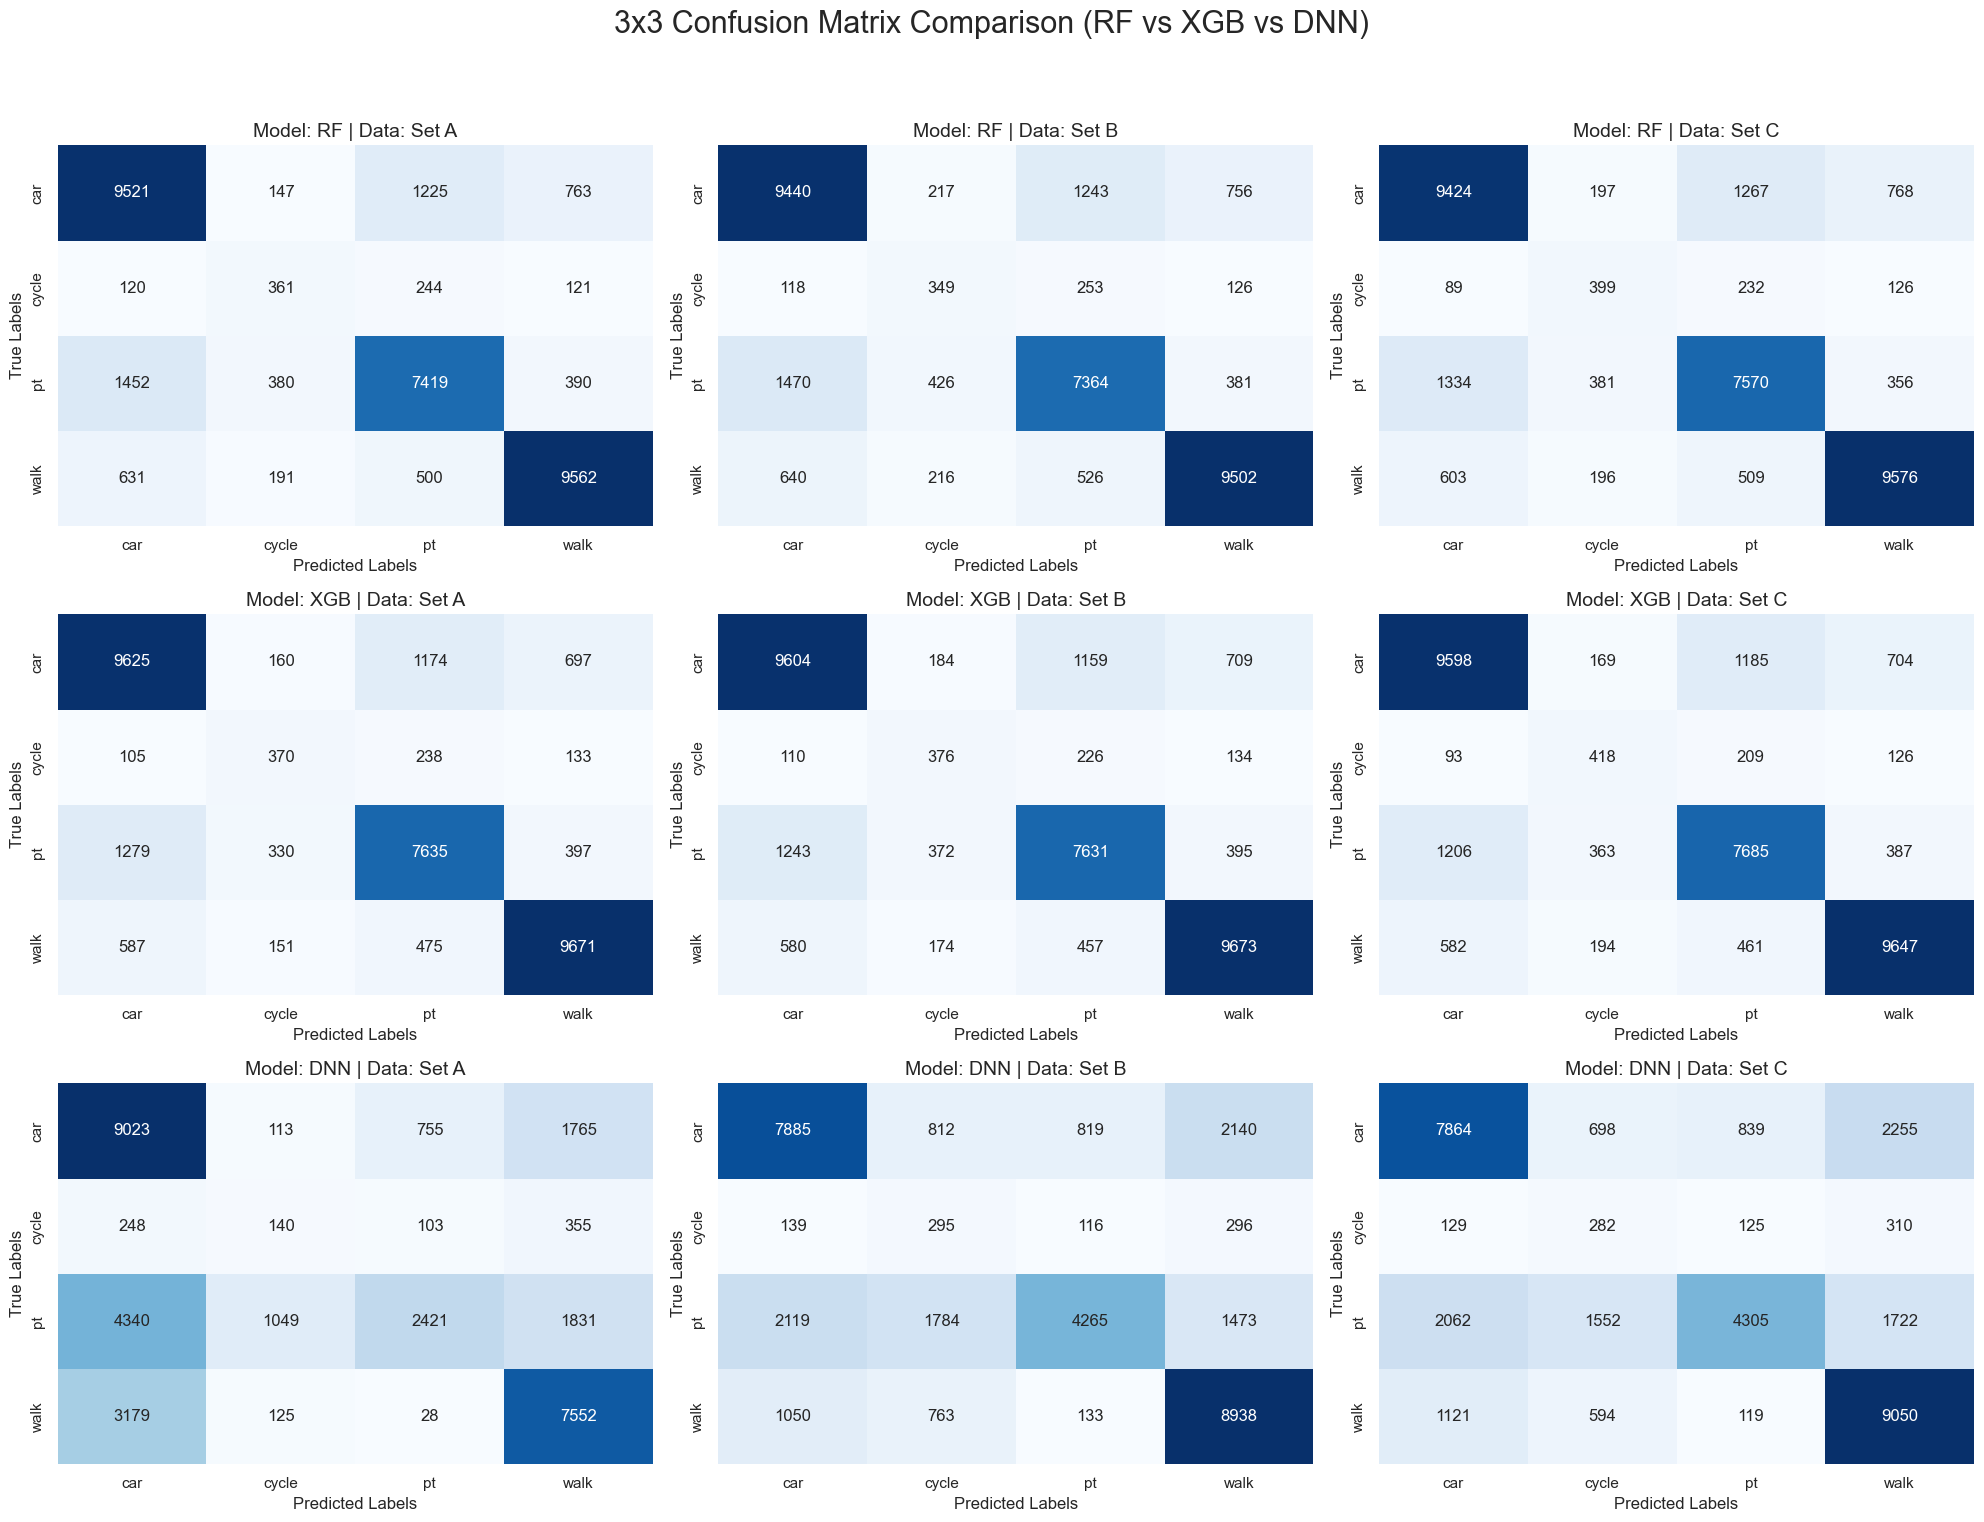

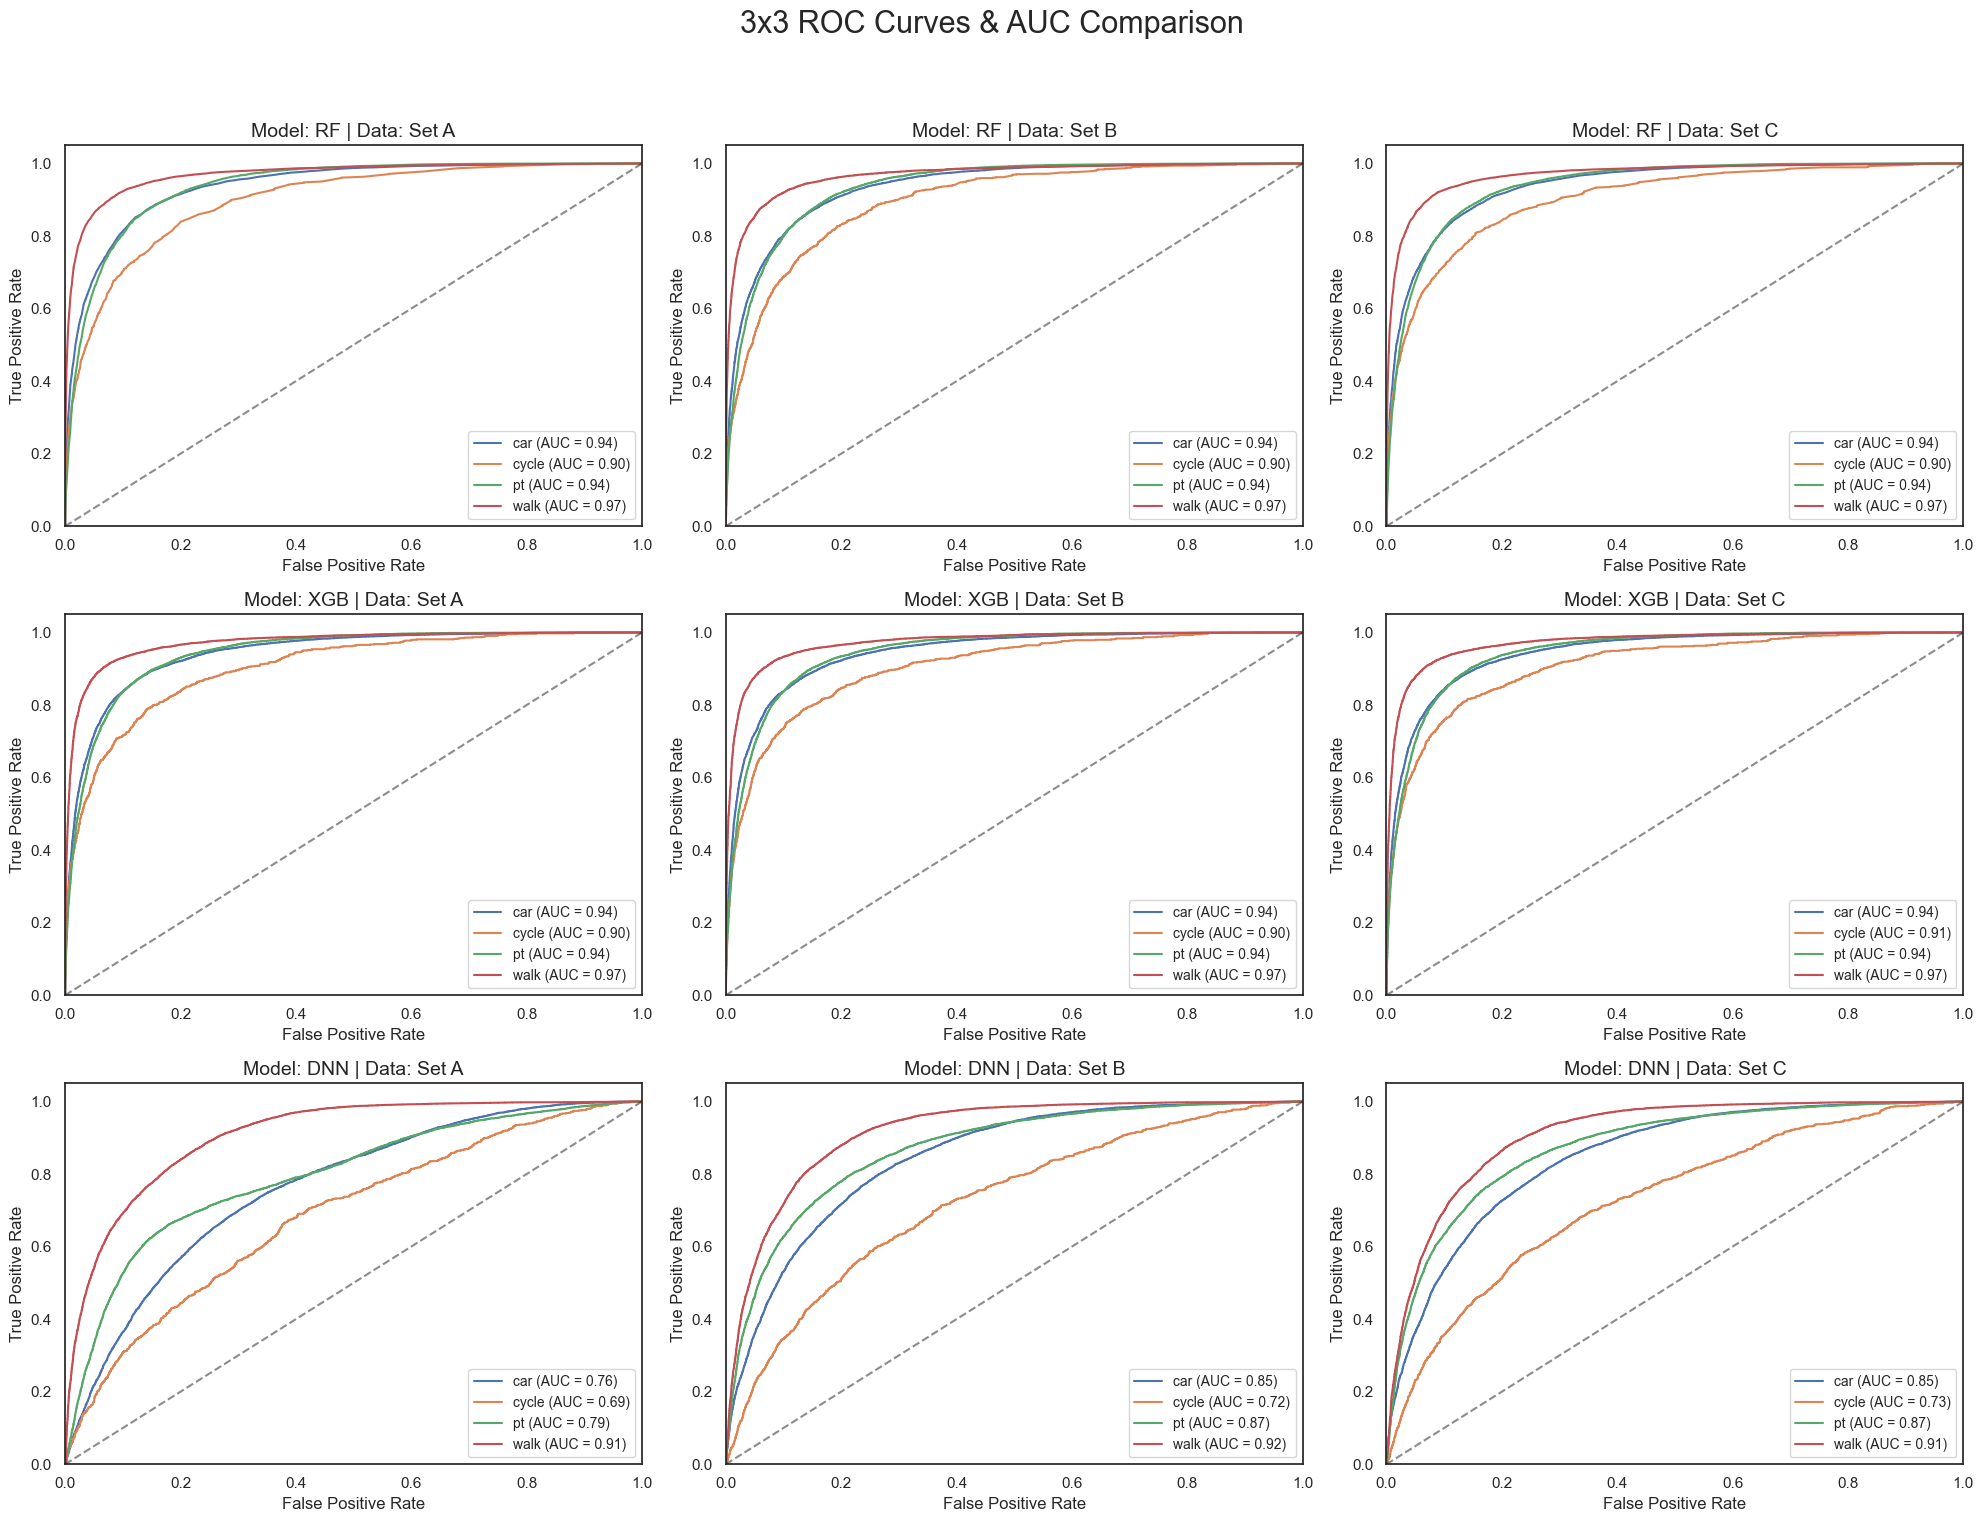


 FINAL MASTER COMPARISON TABLE 
Experiment_Key    ACC    NLL     CK  G-Mean
     XGB_Set C 0.8280 0.4873 0.7485  0.7322
     XGB_Set A 0.8266 0.4880 0.7459  0.7100
     XGB_Set B 0.8261 0.4824 0.7455  0.7124
      RF_Set C 0.8166 0.5357 0.7319  0.7164
      RF_Set A 0.8134 0.5364 0.7267  0.6967
      RF_Set B 0.8071 0.5411 0.7179  0.6870
     DNN_Set C 0.6510 0.8611 0.4996  0.5376
     DNN_Set B 0.6474 0.8843 0.4979  0.5411
     DNN_Set A 0.5794 1.0682 0.3773  0.3865


In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- 1. 配置参数 ---
model_list = ['RF', 'XGB', 'DNN']
set_list = ['Set A', 'Set B', 'Set C']
class_names = le_y.classes_ # 类别名称

# 将标签二值化，用于绘制多分类 ROC 曲线
y_val_bin = label_binarize(y_val_le, classes=range(len(class_names)))
n_classes = len(class_names)

# --- 2. 绘制 3x3 混淆矩阵 (Confusion Matrix) ---
fig_cm, axes_cm = plt.subplots(3, 3, figsize=(20, 16))
fig_cm.suptitle('3x3 Confusion Matrix Comparison (RF vs XGB vs DNN)', fontsize=22)

for i, m_name in enumerate(model_list):
    for j, s_name in enumerate(set_list):
        key = f"{m_name}_{s_name}"
        ax = axes_cm[i, j]
        
        if key in all_preds:
            cm = confusion_matrix(y_val_le, all_preds[key])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        xticklabels=class_names, yticklabels=class_names, cbar=False)
            ax.set_title(f"Model: {m_name} | Data: {s_name}", fontsize=14)
            ax.set_xlabel('Predicted Labels')
            ax.set_ylabel('True Labels')
        else:
            ax.text(0.5, 0.5, f'Missing Data:\n{key}', ha='center', va='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- 3. 绘制 3x3 ROC 曲线 ---
fig_roc, axes_roc = plt.subplots(3, 3, figsize=(20, 16))
fig_roc.suptitle('3x3 ROC Curves & AUC Comparison', fontsize=22)

for i, m_name in enumerate(model_list):
    for j, s_name in enumerate(set_list):
        key = f"{m_name}_{s_name}"
        ax = axes_roc[i, j]
        
        if key in all_probs:
            # 为每个类别画一条 ROC 曲线
            for k in range(n_classes):
                fpr, tpr, _ = roc_curve(y_val_bin[:, k], all_probs[key][:, k])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f'{class_names[k]} (AUC = {roc_auc:.2f})')
            
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.5) # 对角基准线
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f"Model: {m_name} | Data: {s_name}", fontsize=14)
            ax.legend(loc="lower right", fontsize='small')
        else:
            ax.text(0.5, 0.5, f'Missing Data:\n{key}', ha='center', va='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 显示图像
plt.show()

# --- 4. 额外步骤：生成全模型对比大表 ---
master_results = pd.DataFrame.from_dict(all_results, orient='index')
master_results.index.name = 'Experiment_Key'
master_results.reset_index(inplace=True)

print("\n" + "="*80)
print(" FINAL MASTER COMPARISON TABLE ")
print("="*80)
print(master_results.sort_values(by='ACC', ascending=False).to_string(index=False))

**Table X.** Performance comparison of three classifiers across three encoding strategies (best values in bold; for NLL lower is better).

| Model | Encoding | Accuracy ↑ | Neg Log Likelihood (NLL) ↓ | Cohen's Kappa (CK) ↑ | G-Mean ↑ |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **XGBoost** | **Set C (Embedding)** | **0.8280** | **0.4873** | **0.7485** | **0.7322** |
| XGBoost | Set A (Label)   | 0.8266 | 0.4880 | 0.7459 | 0.7100 |
| XGBoost | Set B (One-hot) | 0.8261 | 0.4824 | 0.7455 | 0.7124 |
| **Random Forest** | **Set C (Embedding)** | **0.8166** | **0.5357** | **0.7319** | **0.7164** |
| Random Forest | Set A (Label)   | 0.8134 | 0.5364 | 0.7267 | 0.6967 |
| Random Forest | Set B (One-hot) | 0.8071 | 0.5411 | 0.7179 | 0.6870 |
| **DNN** | **Set C (Embedding)** | **0.6510** | **0.8611** | **0.4996** | **0.5376** |
| DNN | Set B (One-hot) | 0.6474 | 0.8843 | 0.4979 | 0.5411 |
| DNN | Set A (Label)   | 0.5794 | 1.0682 | 0.3773 | 0.3865 |

In [95]:
import pandas as pd

# 1. 重新定义映射逻辑，确保完全对应你的 XGBoost 参数
def map_params_to_image_style(model_type, params):
    if model_type == 'XGB':
        return {
            # 图片名 : 你代码里的参数名
            'feature_fraction': params.get('colsample_bytree', 1.0), 
            'max_depth': params.get('max_depth', 6),
            'leaf_size': params.get('gamma', 0), # 通常用 gamma 或 min_child_weight 对应 leaf 相关限制
            'learning_rate': params.get('learning_rate', 0.1),
            'max_training_rounds': params.get('n_estimators', 100),
            'subsample': params.get('subsample', 0.8)
        }
    elif model_type == 'RF':
        return {
            'feature_fraction': params.get('max_features', 'sqrt'),
            'max_depth': params.get('max_depth', 15),
            'tree_number': params.get('n_estimators', 100),
            'class_weight': params.get('class_weight', None)
        }

    elif model_type == 'DNN':
        return {
            'number of hidden neural size': params.get('hidden_units', '256-128'),
            'number of hidden layer': params.get('num_layers', 2),
            'learning_rate for Adam': params.get('learning_rate', 0.001),
            'dropout rate': params.get('dropout', 0.3)
        }
    return params

# 2. 提取并转换数据
formatted_params = {}
for key, params in all_best_params.items():
    model_prefix = key.split('_')[0] 
    formatted_params[key] = map_params_to_image_style(model_prefix, params)

# 3. 打印符合 VS Code Markdown 语法的表格
def print_final_table(params_dict):
    print("| Methods | Hyperparameters | Set A (Label) | Set B (One-hot) | Set C (Entity) |")
    print("| :--- | :--- | :---: | :---: | :---: |")
    
    for m in ['RF', 'XGB', 'DNN']:
        # 寻找该模型下存在的任意一个 Key 作为参数行模板
        possible_keys = [k for k in params_dict.keys() if k.startswith(m)]
        if not possible_keys: continue
        
        sample_key = possible_keys[0]
        for idx, p_name in enumerate(params_dict[sample_key].keys()):
            # 这里的 get 会去 all_best_params 转换后的字典里找值
            val_a = params_dict.get(f"{m}_Set A", {}).get(p_name, "-")
            val_b = params_dict.get(f"{m}_Set B", {}).get(p_name, "-")
            val_c = params_dict.get(f"{m}_Set C", {}).get(p_name, "-")
            
            method_label = f"**{m}**" if idx == 0 else ""
            print(f"| {method_label} | {p_name} | {val_a} | {val_b} | {val_c} |")
        print("| --- | --- | --- | --- | --- |")

# 执行打印
print_final_table(formatted_params)

| Methods | Hyperparameters | Set A (Label) | Set B (One-hot) | Set C (Entity) |
| :--- | :--- | :---: | :---: | :---: |
| **RF** | feature_fraction | sqrt | sqrt | sqrt |
|  | max_depth | 30 | 30 | 30 |
|  | tree_number | 200 | 200 | 200 |
|  | class_weight | None | None | None |
| --- | --- | --- | --- | --- |
| **XGB** | feature_fraction | 1.0 | 1.0 | 1.0 |
|  | max_depth | 15 | 15 | 15 |
|  | leaf_size | 0.1 | 0.1 | 0.1 |
|  | learning_rate | 0.1 | 0.1 | 0.1 |
|  | max_training_rounds | 200 | 200 | 200 |
|  | subsample | 0.8 | 0.8 | 0.8 |
| --- | --- | --- | --- | --- |
| **DNN** | number of hidden neural size | 256-128 | 256-128 | 256-128 |
|  | number of hidden layer | 2 | 2 | 2 |
|  | learning_rate for Adam | 0.001 | 0.001 | 0.001 |
|  | dropout rate | 0.3 | 0.3 | 0.3 |
| --- | --- | --- | --- | --- |


**Table X.** Summary of Optimal Model Parameters

| Methods | Hyperparameters | Set A (Label) | Set B (One-hot) | Set C (Entity) |
| :--- | :--- | :---: | :---: | :---: |
| **RF** | feature_fraction | sqrt | sqrt | sqrt |
|  | max_depth | 30 | 30 | 30 |
|  | tree_number | 200 | 200 | 200 |
|  | class_weight | None | None | None |
| **XGB** | feature_fraction | 1.0 | 1.0 | 1.0 |
|  | max_depth | 15 | 15 | 15 |
|  | leaf_size | 0.1 | 0.1 | 0.1 |
|  | learning_rate | 0.1 | 0.1 | 0.1 |
|  | max_training_rounds | 200 | 200 | 200 |
|  | subsample | 0.8 | 0.8 | 0.8 |
| **DNN** | number of hidden neural size | 256-128 | 256-128 | 256-128 |
|  | number of hidden layer | 2 | 2 | 2 |
|  | learning_rate for Adam | 0.001 | 0.001 | 0.001 |
|  | dropout rate | 0.3 | 0.3 | 0.3 |